# Lab 3: Ensembles
## Using trees to detect trees 

We will be using tree-based ensemble methods on the [Covertype dataset](https://www.openml.org/d/180).
It contains about 100,000 observations of 7 types of trees (Spruce, Pine, Cottonwood, Aspen,...) described by 55 features describing elevation, distance to water, soil type, etc.

In [1]:
# Auto-setup when running on Google Colab
if 'google.colab' in str(get_ipython()):
    !pip install openml

# General imports
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openml as oml
import seaborn as sns

In [2]:
# Download Covertype data. Takes a while the first time.
covertype = oml.datasets.get_dataset(180)
X, y, _, _ = covertype.get_data(target=covertype.default_target_attribute, dataset_format='array'); 
classes = covertype.retrieve_class_labels()
features = [f.name for i,f in covertype.features.items()][:-1]

C:\Users\20202369\AppData\Local\Temp\ipykernel_21948\2692424945.py:3: FutureWarning: Support for `dataset_format='array'` will be removed in 0.15,start using `dataset_format='dataframe' to ensure your code will continue to work. You can use the dataframe's `to_numpy` function to continue using numpy arrays.
  X, y, _, _ = covertype.get_data(target=covertype.default_target_attribute, dataset_format='array');


In [3]:
classes

['Aspen',
 'Cottonwood_Willow',
 'Douglas_fir',
 'Krummholz',
 'Lodgepole_Pine',
 'Ponderosa_Pine',
 'Spruce_Fir']

In [4]:
features[0:20]

['elevation',
 'aspect',
 'slope',
 'horizontal_distance_to_hydrology',
 'Vertical_Distance_To_Hydrology',
 'Horizontal_Distance_To_Roadways',
 'Hillshade_9am',
 'Hillshade_Noon',
 'Hillshade_3pm',
 'Horizontal_Distance_To_Fire_Points',
 'wilderness_area1',
 'wilderness_area2',
 'wilderness_area3',
 'wilderness_area4',
 'soil_type_1',
 'soil_type_2',
 'soil_type_3',
 'soil_type_4',
 'soil_type_5',
 'soil_type_6']

To understand the data a bit better, we can use a scatter matrix. From this, it looks like elevation is a relevant feature.
Douglas Fir and Aspen grow at low elevations, while only Krummholz pines survive at very high elevations.

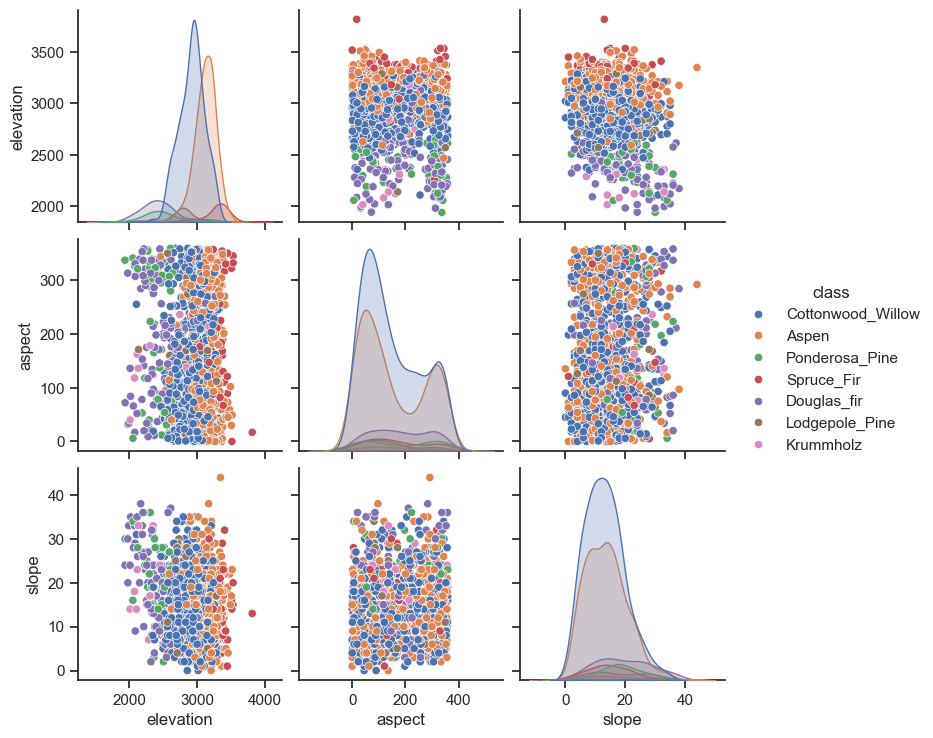

In [5]:
# Using seaborn to build the scatter matrix
# only first 3 columns, first 1000 examples
n_points = 1500
df = pd.DataFrame(X[:n_points,:3], columns=features[:3])
df['class'] = [classes[i] for i in y[:n_points]]
sns.set(style="ticks")
sns.pairplot(df, hue="class");

## Exercise 1: Random Forests
Implement a function `evaluate_RF` that measures the performance of a Random Forest Classifier, using trees
of (max) depth 2,8,32,64, for any number of trees in the ensemble (`n_estimators`). 
For the evaluation you should measure accuracy using 3-fold cross-validation. 
Use `random_state=1` to ensure reproducibility. Finally, plot the results for at least 5 values of `n_estimators` ranging from 1 to 30. You can, of course, reuse code from earlier labs and assignments. Interpret the results.
You can take a 50% subsample to speed the plotting.

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def evaluate_RF(X, y, eval_measure, param_grid):


    grid = GridSearchCV(RandomForestClassifier(random_state=1), param_grid=param_grid, cv=3, scoring=eval_measure, return_train_score=True)


    X_train, _, y_train, _ = train_test_split(
        X, y, random_state=1)
    
    grid.fit(X_train, y_train)

    scores = grid.cv_results_['mean_test_score']
    scores = scores.reshape(len(param_grid['max_depth']), len(param_grid['n_estimators']))

    plt.figure(figsize=(10, 6))
    for i, depth in enumerate(param_grid['max_depth']):
        plt.plot(param_grid['n_estimators'], scores[i, :], 
                 marker='o', label=f'max_depth={depth}')
    
    plt.xlabel('Number of Trees (n_estimators)')
    plt.ylabel('Mean CV Accuracy')
    plt.title('Random Forest Performance by Tree Depth and Number of Trees')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return grid



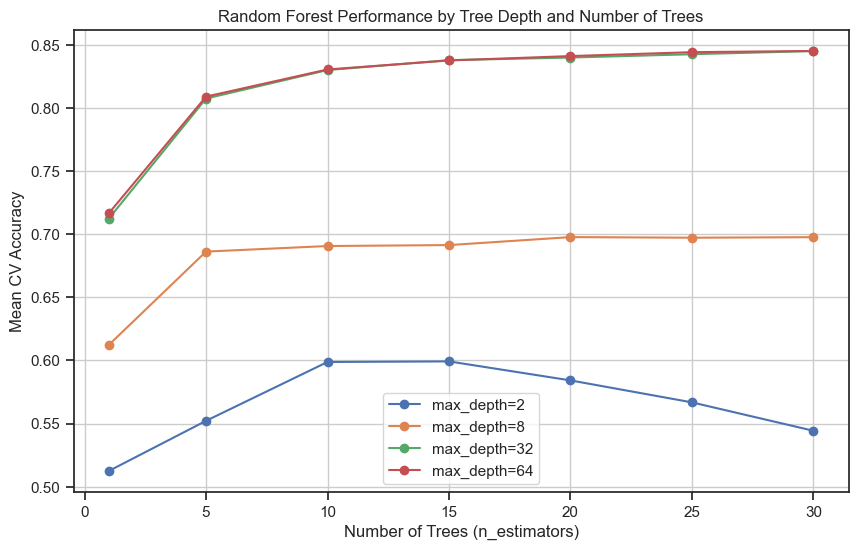

In [7]:
param_grid = {
    "max_depth": [2, 8, 32, 64],
    "n_estimators": [1, 5, 10, 15, 20, 25, 30]
}

grid = evaluate_RF(X, y, None, param_grid)

## Exercise 2: Other measures
Repeat the same plot but now use balanced_accuracy as the evaluation measure. See the [documentation](https://scikit-learn.org/stable/modules/model_evaluation.html#balanced-accuracy-score).
Only use the optimal max_depth from the previous question. Do you see an important difference?

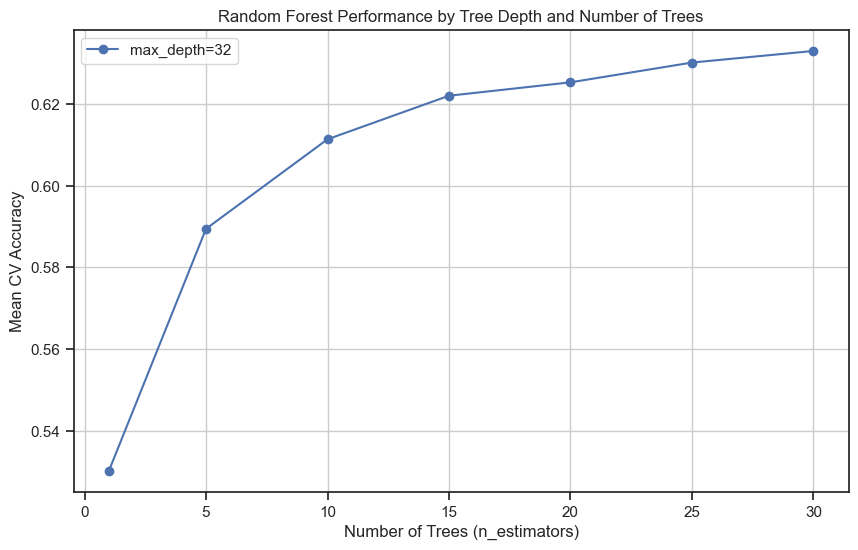

In [8]:
from sklearn.metrics import balanced_accuracy_score, make_scorer

param_grid_estimator = {
    "max_depth": [32],
    "n_estimators": [1, 5, 10, 15, 20, 25, 30]
}

balanced_accuracy = make_scorer(balanced_accuracy_score)

grid_balanced = evaluate_RF(X,y,balanced_accuracy, param_grid_estimator)

## Exercise 3: Feature importance
Retrieve the feature importances according to the (tuned) random forest model. Which feature are most important?

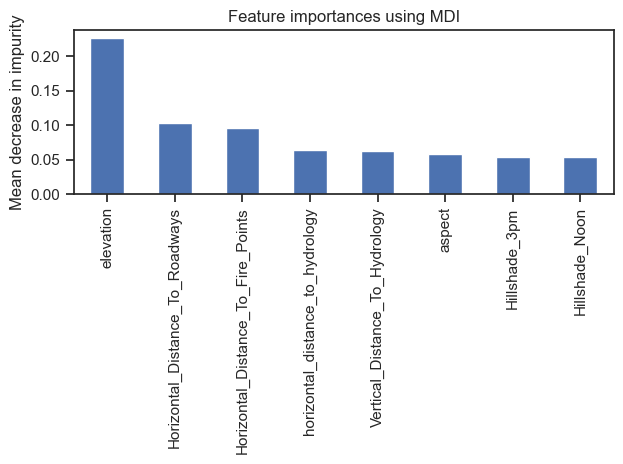

In [9]:
importances = grid_balanced.best_estimator_.feature_importances_

forest_importances = pd.Series(importances, index=features)

sorted_importances = forest_importances.sort_values(ascending=False)

fig, ax = plt.subplots()
sorted_importances[:8].plot.bar(ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()


## Exercise 4: Feature selection
Re-build your tuned random forest, but this time only using the first 10 features.
Return both the balanced accuracy and training time. Interpret the results.

In [10]:
sorted_importances.head(10)

elevation                             0.225851
Horizontal_Distance_To_Roadways       0.102658
Horizontal_Distance_To_Fire_Points    0.096320
horizontal_distance_to_hydrology      0.063936
Vertical_Distance_To_Hydrology        0.061877
aspect                                0.058028
Hillshade_3pm                         0.053509
Hillshade_Noon                        0.052985
Hillshade_9am                         0.052461
slope                                 0.044179
dtype: float64

In [11]:
top_10_features = sorted_importances.head(10).index.tolist()

X_top_10 = X[:, [features.index(feat) for feat in top_10_features]]


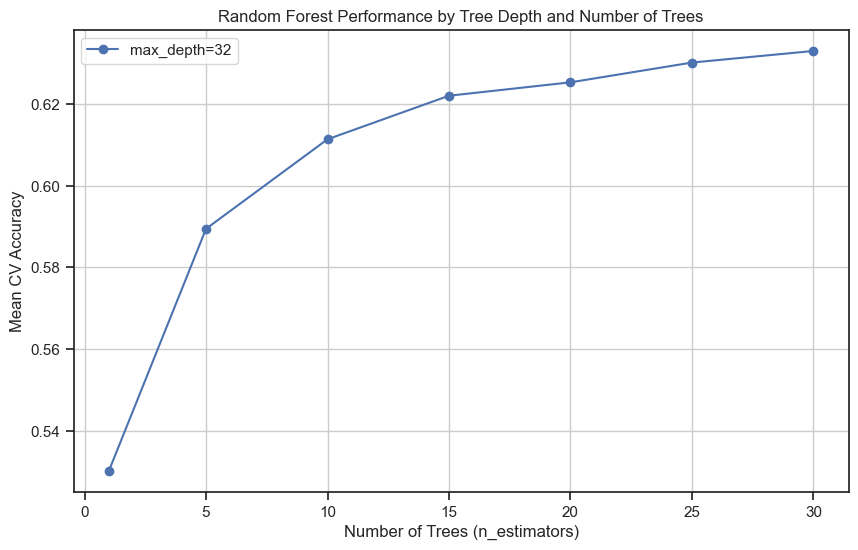

In [12]:
grid_top_10 = evaluate_RF(X,y,balanced_accuracy, param_grid_estimator)

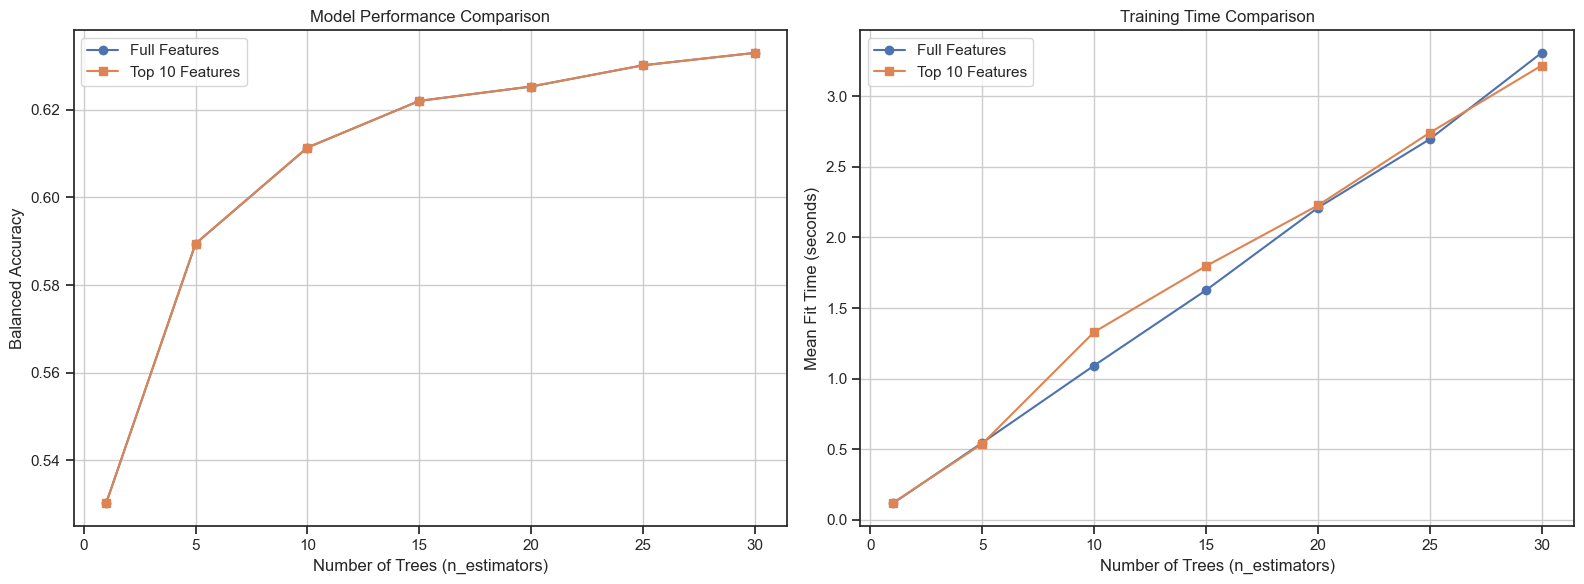

In [19]:
# Extract the n_estimators values
n_estimators = param_grid_estimator['n_estimators']

# Extract results
scores_full = grid_balanced.cv_results_['mean_test_score']
times_full = grid_balanced.cv_results_['mean_fit_time']

scores_top10 = grid_top_10.cv_results_['mean_test_score']
times_top10 = grid_top_10.cv_results_['mean_fit_time']

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot balanced accuracy comparison
ax1.plot(n_estimators, scores_full, marker='o', label='Full Features')
ax1.plot(n_estimators, scores_top10, marker='s', label='Top 10 Features')
ax1.set_xlabel('Number of Trees (n_estimators)')
ax1.set_ylabel('Balanced Accuracy')
ax1.set_title('Model Performance Comparison')
ax1.legend()
ax1.grid(True)

# Plot training time comparison
ax2.plot(n_estimators, times_full, marker='o', label='Full Features')
ax2.plot(n_estimators, times_top10, marker='s', label='Top 10 Features')
ax2.set_xlabel('Number of Trees (n_estimators)')
ax2.set_ylabel('Mean Fit Time (seconds)')
ax2.set_title('Training Time Comparison')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Exercise 5: Confusion matrix
Do a standard stratified holdout and generate the confusion matrix of the tuned random forest. Which classes are still often confused?

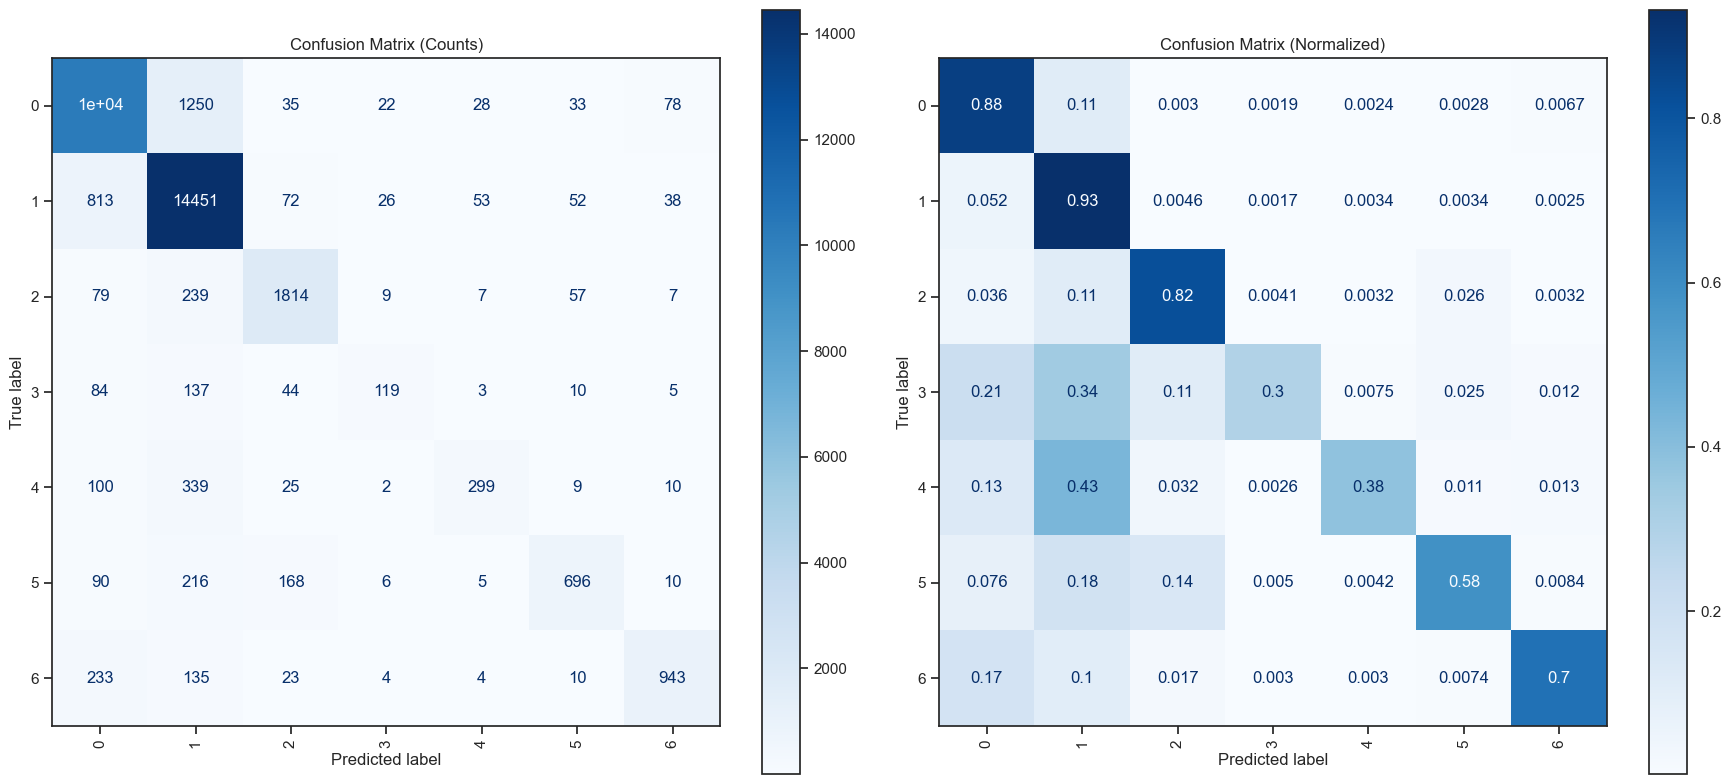

Most confused class pairs:
Top 5 most confused class pairs (true_class, predicted_class, count, percentage):
1. Class 0 confused as Class 1: 1250 instances (10.71%)
2. Class 1 confused as Class 0: 813 instances (5.24%)
3. Class 4 confused as Class 1: 339 instances (43.24%)
4. Class 2 confused as Class 1: 239 instances (10.80%)
5. Class 6 confused as Class 0: 233 instances (17.23%)


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Get the best model from your tuned random forest
best_rf = grid_balanced.best_estimator_

# Perform stratified holdout (ensures class proportions are maintained)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# Fit the model on training data
best_rf.fit(X_train, y_train)

# Make predictions on test data
y_pred = best_rf.predict(X_test)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Normalize confusion matrix by row (true labels) to see proportions of each class
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create a visualization of the confusion matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Plot raw counts
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm)
disp1.plot(ax=ax1, cmap='Blues', xticks_rotation='vertical')
ax1.set_title('Confusion Matrix (Counts)')

# Plot normalized version
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_normalized)
disp2.plot(ax=ax2, cmap='Blues', xticks_rotation='vertical')
ax2.set_title('Confusion Matrix (Normalized)')

plt.tight_layout()
plt.show()

# Find most confused class pairs
print("Most confused class pairs:")
n_classes = cm.shape[0]
confused_pairs = []

for i in range(n_classes):
    for j in range(n_classes):
        if i != j:
            confused_pairs.append((i, j, cm[i, j], cm[i, j]/sum(cm[i])))

# Sort by number of misclassifications (descending)
confused_pairs.sort(key=lambda x: x[2], reverse=True)

# Print top 5 most confused pairs
print("Top 5 most confused class pairs (true_class, predicted_class, count, percentage):")
for i, (true_class, pred_class, count, percentage) in enumerate(confused_pairs[:5]):
    print(f"{i+1}. Class {true_class} confused as Class {pred_class}: {count} instances ({percentage:.2%})")

## Exercise 6: A second-level model
Build a binary model specifically to correctly choose between the first and the second class.
Select only the data points with those classes and train a new random forest. Do a standard stratified split and plot the resulting ROC curve. Can we still improve the model by calibrating the threshold?

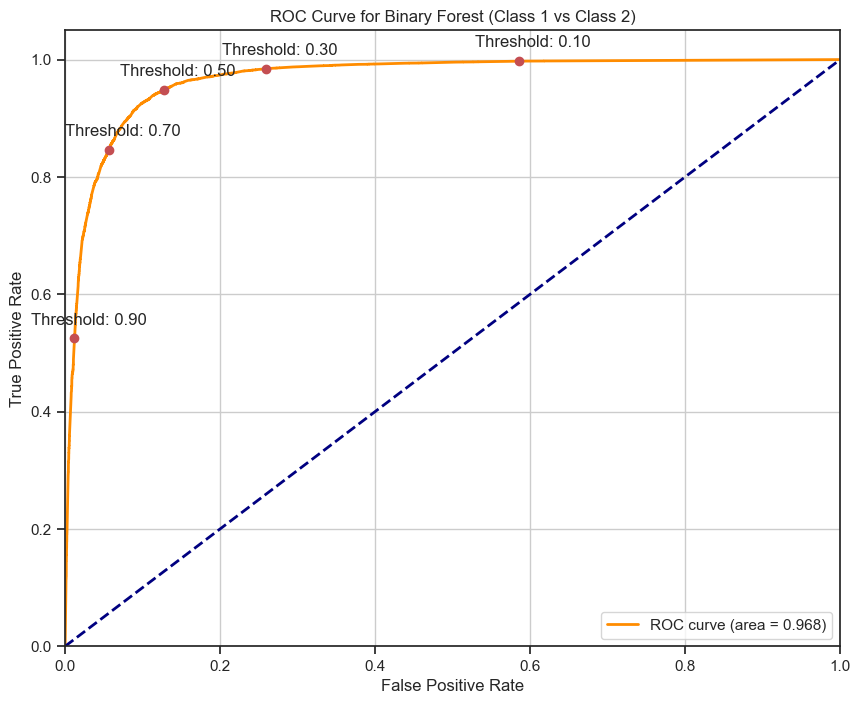

Default threshold (0.5) performance:
Accuracy: 0.9158

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90     11672
           1       0.91      0.95      0.93     15505

    accuracy                           0.92     27177
   macro avg       0.92      0.91      0.91     27177
weighted avg       0.92      0.92      0.92     27177


Confusion Matrix:
[[10228  1444]
 [  844 14661]]

Optimal threshold: 0.5658
Accuracy with optimal threshold: 0.9150

Classification Report with optimal threshold:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     11672
           1       0.93      0.92      0.93     15505

    accuracy                           0.92     27177
   macro avg       0.91      0.91      0.91     27177
weighted avg       0.92      0.92      0.92     27177


Confusion Matrix with optimal threshold:
[[10529  1143]
 [ 1167 14338]]


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score, classification_report, confusion_matrix

# Extract only the data points belonging to the first two classes
# Assuming classes are labeled starting from 0 or 1
first_class = min(np.unique(y))
second_class = sorted(np.unique(y))[1]

# Filter the data to include only these two classes
mask = np.isin(y, [first_class, second_class])
X_binary = X[mask]
y_binary = y[mask]

# Convert to binary labels (0 and 1)
y_binary = (y_binary == second_class).astype(int)

# Create a stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=1, stratify=y_binary)

# Train a Random Forest with the best parameters from previous exercises
# Assuming max_depth=32 and optimal n_estimators was found
rf_binary = RandomForestClassifier(
    max_depth=32, 
    n_estimators=grid_balanced.best_params_['n_estimators'],
    random_state=42
)
rf_binary.fit(X_train, y_train)

# Generate predictions and probabilities
y_pred = rf_binary.predict(X_test)
y_proba = rf_binary.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Binary Forest (Class 1 vs Class 2)')
plt.legend(loc="lower right")
plt.grid(True)

# Add some threshold markers
selected_thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
threshold_indices = [np.abs(thresholds - t).argmin() for t in selected_thresholds]
for idx in threshold_indices:
    plt.plot(fpr[idx], tpr[idx], 'ro')
    plt.annotate(f'Threshold: {thresholds[idx]:.2f}', 
                 (fpr[idx], tpr[idx]), 
                 textcoords="offset points", 
                 xytext=(10,10), 
                 ha='center')

plt.show()

# Analyze threshold impact on accuracy
print("Default threshold (0.5) performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Find optimal threshold for balanced classification
# This is especially useful if classes are imbalanced
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

print(f"\nOptimal threshold: {optimal_threshold:.4f}")
print(f"Accuracy with optimal threshold: {accuracy_score(y_test, y_pred_optimal):.4f}")
print("\nClassification Report with optimal threshold:")
print(classification_report(y_test, y_pred_optimal))
print("\nConfusion Matrix with optimal threshold:")
print(confusion_matrix(y_test, y_pred_optimal))

## Exercise 7: Model calibration
For the trained binary random forest model, plot a calibration curve (see [course notebook](https://ml-course.github.io/engineer/slides_html/03%20-%20Model%20Selection.slides.html#/40)). 
Next, try to correct for this using Platt Scaling (or sigmoid scaling).

Probability calibration should be done on new data not used for model fitting. The class [CalibratedClassifierCV](https://scikit-learn.org/stable/auto_examples/calibration/plot_calibration_curve.html#sphx-glr-auto-examples-calibration-plot-calibration-curve-py) uses a cross-validation generator and estimates for each split the model parameter on the train samples and the calibration of the test samples. The probabilities predicted for the folds are then averaged. Already fitted classifiers can be calibrated by CalibratedClassifierCV via the parameter cv=”prefit”. [Read more](https://scikit-learn.org/stable/modules/calibration.html)

## Exercise 8: Gradient Boosting
Implement a function `evaluate_GB` that measures the performance of `GradientBoostingClassifier` or the `XGBoostClassifier` for 
different learning rates (0.01, 0.1, 1, and 10). As before, use a 3-fold cross-validation. You can use a 5% stratified sample of the whole dataset.
Finally plot the results for `n_estimators` ranging from 1 to 100. Run all the GBClassifiers with `random_state=1` to ensure reproducibility.

Implement a function that plots the score of `evaluate_GB` for `n_estimators` = 10,20,30,...,100 on a linear scale.